Change conda enviroment to `schedule`

In [3]:
from lightcode import main
from lightcode import models
from lightcode import hardware
import numpy as np
import matplotlib.pyplot as plt

# Single Sim Result

In [4]:
CPU_AVERAGE_CLOCK = 3.208 * 10**9  # 60**9, 6
PHU_MIN_CLOCK = 9.7 * 10**9  # 100**9, 10 Ghz
GPU_FP32_CLOCK = 1.98 * 10**9  # 1.98 GHz

local_hardware = []
main.hardware.Hardware._hardware_reset()
local_hardware.append(main.hardware.CPU(CPU_AVERAGE_CLOCK, 1)) # 1 core
local_hardware.append(main.hardware.PHU(PHU_MIN_CLOCK, 1, 20)) # 1 core, 20 multiplex factor

GPC = 8  # Graphical Processing Clusters
TPC_per_GPC = 9  # Texture Processing Clusters/Graphical Processing Cluster
SM_per_TPC = 2  # Streaming multiprocessors / Texture Processing Cluster
fp32_CUDA_cores_per_SM = 128  # fp32_CUDA_cores / Streaming multiprocessor
TC_per_SM = 4  # Tensor Cores / Streaming multiprocessor
local_hardware.append(main.hardware.GPU(
        GPU_FP32_CLOCK,
        GPC,
        TPC_per_GPC,
        SM_per_TPC,
        fp32_CUDA_cores_per_SM,
        TC_per_SM,
    )
)

# Everythin you define should be used in initilize_hardware
available_hardware = main.hardware.initilize_hardware(local_hardware)


# optimization = "time"
optimization = "energy"
# optimization = "always_phu"


ans = main.graph_search(
    models.gpt2_prefill,
    optimization,
    available_hardware,
    moc_sequence_length=50,
    profiles=True,
    colect_data=True,
)
print(ans)

{'moc_sequence_length': 50, 'Makespan': 0.04984, 'num_nodes': 1518, 'total_energy': 43079811496.0, 'num_photonic': 73, 'posiable_photonic': 73}


# Ploting Hardware Results

In [48]:
sequence_len = []
cpu_time = []
cpu_energy = []
cpu_phu_time = []
cpu_phu_energy = []
gpu_time = []
gpu_energy = []
gpu_phu_time = []
gpu_phu_energy = []

optimization = "time"

CPU_AVERAGE_CLOCK = 3.208 * 10**9  # 60**9, 6
PHU_MIN_CLOCK = 9.7 * 10**9  # 100**9, 10 Ghz
GPU_FP32_CLOCK = 1.98 * 10**9  # 1.98 GHz

GPC = 8                         # Graphical Processing Clusters
TPC_per_GPC = 9                 # Texture Processing Clusters/Graphical Processing Cluster
SM_per_TPC = 2                  # Streaming multiprocessors / Texture Processing Cluster
fp32_CUDA_cores_per_SM = 128    # fp32_CUDA_cores / Streaming multiprocessor
TC_per_SM = 4                   # Tensor Cores / Streaming multiprocessor

model = models.gpt2_prefill

iterations = 20
start, stop = 0, 60000
for i in range(iterations):
    len = int(np.exp(i / (iterations - 1) * np.log(stop)))

    sequence_len.append(len)

    ### cpu
    local_hardware = []
    hardware.Hardware._hardware_reset()
    local_hardware.append(hardware.CPU(CPU_AVERAGE_CLOCK, 1))
    available_hardware = hardware.initilize_hardware(local_hardware)

    ans = main.graph_search(
        model,
        optimization,
        available_hardware,
        moc_sequence_length = len,
        profiles=True,
        colect_data=True,
    )
    cpu_time.append(ans['Makespan'])
    cpu_energy.append(ans['total_energy'])

    ### cpu_phu
    local_hardware = []
    hardware.Hardware._hardware_reset()
    local_hardware.append(hardware.CPU(CPU_AVERAGE_CLOCK, 1))
    local_hardware.append(main.hardware.PHU(PHU_MIN_CLOCK, 1, 20))
    available_hardware = hardware.initilize_hardware(local_hardware)

    ans = main.graph_search(
        model,
        optimization,
        available_hardware,
        moc_sequence_length = len,
        profiles=True,
        colect_data=True,
    )
    cpu_phu_time.append(ans['Makespan'])
    cpu_phu_energy.append(ans['total_energy'])

    ### gpu
    local_hardware = []
    hardware.Hardware._hardware_reset()
    local_hardware.append(main.hardware.GPU(
            GPU_FP32_CLOCK,
            GPC,
            TPC_per_GPC,
            SM_per_TPC,
            fp32_CUDA_cores_per_SM,
            TC_per_SM,
        )
    )
    available_hardware = hardware.initilize_hardware(local_hardware)

    ans = main.graph_search(
        model,
        optimization,
        available_hardware,
        moc_sequence_length = len,
        profiles=True,
        colect_data=True,
    )
    gpu_time.append(ans['Makespan'])
    gpu_energy.append(ans['total_energy'])


    ### gpu_phu
    local_hardware = []
    hardware.Hardware._hardware_reset()
    local_hardware.append(main.hardware.GPU(
            GPU_FP32_CLOCK,
            GPC,
            TPC_per_GPC,
            SM_per_TPC,
            fp32_CUDA_cores_per_SM,
            TC_per_SM,
        )
    )
    local_hardware.append(main.hardware.PHU(PHU_MIN_CLOCK, 1, 20))
    available_hardware = hardware.initilize_hardware(local_hardware)

    ans = main.graph_search(
        model,
        optimization,
        available_hardware,
        moc_sequence_length = len,
        profiles=True,
        colect_data=True,
    )
    # print(ans['num_photonic'])
    gpu_phu_time.append(ans['Makespan'])
    gpu_phu_energy.append(ans['total_energy'])


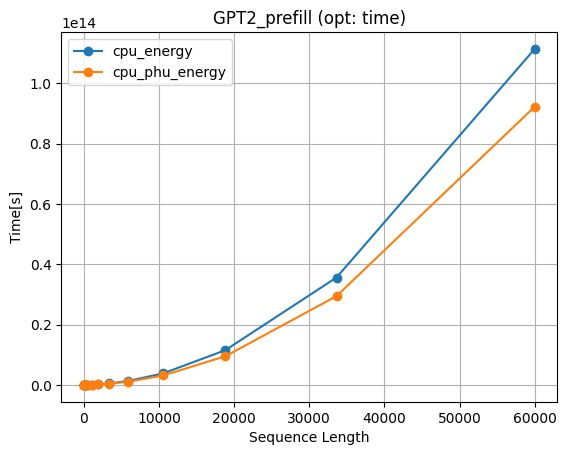

In [51]:
cpu_time
cpu_energy
cpu_phu_time
cpu_phu_energy
gpu_time
gpu_energy
gpu_phu_time
gpu_phu_energy

# plt.plot(sequence_len, cpu_time, marker='o', label ='cpu_time')
# plt.plot(sequence_len, cpu_phu_time, marker='o', label ='cpu_phu_time')
# plt.plot(sequence_len, gpu_time, marker='o', label ='gpu_time')
# plt.plot(sequence_len, gpu_phu_time, marker='o', label ='gpu_phu_time')

plt.plot(sequence_len, cpu_energy, marker='o', label ='cpu_energy')
plt.plot(sequence_len, cpu_phu_energy, marker='o', label ='cpu_phu_energy')
# plt.plot(sequence_len, gpu_energy, marker='o', label ='gpu_energy')
# plt.plot(sequence_len, gpu_phu_energy, marker='o', label ='gpu_phu_energy')

plt.title(f'GPT2_prefill (opt: time)')
plt.xlabel('Sequence Length')
# plt.ylabel('Time[s]')
plt.ylabel('energy[pJ]')

# plt.xscale("log")
# plt.yscale("log")


plt.grid(True)
plt.legend()
plt.show()

# Ploting Core Differences

sequence_len = []
core_count = []
time = []
energy = []

